# Evaluación de Modelos de Machine Learning con KNN

Este notebook realiza un análisis completo de clasificación utilizando el algoritmo K-Nearest Neighbors (KNN) sobre el dataset de Abalone. El objetivo es evaluar el rendimiento del modelo con diferentes valores de K mediante validación cruzada.

## 1. Importación de Librerías

Comenzamos importando todas las librerías necesarias para el análisis:
- **pandas y numpy**: Para manipulación de datos
- **seaborn y matplotlib**: Para visualización
- **sklearn**: Para preprocesamiento, modelado y evaluación

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler


## 2. Carga y Exploración del Dataset

Cargamos el dataset de Abalone desde un archivo CSV con separador punto y coma (`;`). Este dataset contiene información sobre características físicas de abalones (moluscos marinos). 

Verificamos las dimensiones del dataset para conocer la cantidad de registros (filas) y características (columnas) disponibles.

In [3]:
df = pd.read_csv('abalone.csv', sep=";")
print("Filas:", df.shape[0], "Columnas:", df.shape[1])
df.sample(5)  # Muestra 5 filas aleatorias del DataFrame

Filas: 3676 Columnas: 10


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Adulto
1929,M,0.615,0.495,0.200,1.2190,0.5640,0.2270,0.3885,10,1
605,I,0.425,0.345,0.125,0.4250,0.1600,0.0795,0.1540,13,1
3404,F,0.650,0.475,0.165,13.8750,0.5800,0.3485,0.3095,9,0
2965,M,0.670,0.525,0.195,14.4050,0.6595,0.2675,0.4250,9,0
3666,I,0.405,0.300,0.085,0.3035,0.1500,0.0505,0.0880,7,0


## 3. Preparación de Variables

Separamos el dataset en:
- **X (Features)**: Variables predictoras - se eliminan las columnas 'Adulto' (variable objetivo) y 'Sex' (variable categórica)
- **y (Target)**: Variable objetivo 'Adulto' que indica si el abalone es adulto o no

Esta separación es fundamental para entrenar modelos de aprendizaje supervisado.

In [4]:
X=df.drop(['Adulto', 'Sex'], axis=1)
y=df['Adulto']

## 4. Análisis de la Distribución de Clases

Verificamos la distribución de la variable objetivo para identificar posibles desbalances en las clases. Esto es importante porque:
- Un desbalance significativo puede afectar el rendimiento del modelo
- Nos ayuda a decidir si necesitamos técnicas de balanceo
- Permite interpretar correctamente las métricas de evaluación

In [5]:
print(y.groupby(y).count())

Adulto
0    2073
1    1603
Name: Adulto, dtype: int64


## 5. División en Conjuntos de Entrenamiento y Prueba

Dividimos los datos en:
- **70% para entrenamiento** (X_train, y_train): Para entrenar el modelo
- **30% para prueba** (X_test, y_test): Para evaluar el rendimiento final

Utilizamos `random_state=56` para garantizar reproducibilidad de los resultados. Esta división nos permite evaluar cómo generaliza el modelo con datos no vistos durante el entrenamiento.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=56)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2573, 8) (1103, 8) (2573,) (1103,)


## 6. Estandarización de Variables

Aplicamos `StandardScaler` para normalizar las características:
- **¿Por qué?** KNN es sensible a la escala de las variables porque usa distancias
- **Proceso**: Transforma cada variable para tener media=0 y desviación estándar=1
- **Importante**: Ajustamos el scaler solo con datos de entrenamiento (`fit_transform`) y lo aplicamos a los datos de prueba (`transform`) para evitar data leakage

In [7]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_test = pd.DataFrame(scaler.transform(X_test))

## 7. Configuración del Modelo KNN

Creamos una instancia del clasificador K-Nearest Neighbors y exploramos sus parámetros por defecto.

**Parámetros importantes de KNN:**
- `n_neighbors`: Número de vecinos más cercanos a considerar (por defecto: 5)
- `weights`: Peso de los vecinos ('uniform' o 'distance')
- `metric`: Medida de distancia utilizada (por defecto: 'minkowski')

In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

## 8. Configuración de Validación Cruzada Estratificada

Creamos una estrategia de validación cruzada con `StratifiedKFold`:
- **10 folds**: Divide los datos en 10 subconjuntos
- **Estratificada**: Mantiene la proporción de clases en cada fold
- **Shuffle=True**: Mezcla los datos antes de dividirlos
- **random_state=19**: Para reproducibilidad

Esta técnica nos permite evaluar el modelo de manera más robusta, utilizando todos los datos tanto para entrenamiento como para validación.

In [9]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=19)

## 9. Evaluación de Diferentes Valores de K

Realizamos un **Grid Search manual** para encontrar el valor óptimo de K:
- Probamos valores de K desde 1 hasta 30
- Para cada K, entrenamos el modelo usando validación cruzada de 10 folds
- Calculamos la precisión (accuracy) promedio de los 10 folds
- Almacenamos los resultados para su posterior análisis

Este proceso nos permite identificar el valor de K que maximiza el rendimiento del modelo.

In [10]:
from sklearn.model_selection import cross_val_score
k_range = list(range(1, 31))
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=folds, scoring='accuracy')
    k_scores.append(scores.mean())

## 10. Visualización de Resultados Numéricos

Mostramos la precisión obtenida para cada valor de K de forma detallada. Esto nos permite:
- Identificar el valor de K con mejor rendimiento
- Observar la tendencia de la precisión
- Detectar valores de K que producen sobreajuste (overfitting) o subajuste (underfitting)

In [11]:
for i, value in enumerate(k_scores):
    print('K=', i+1, ':', '%.4f' % value, '"""', end='', sep='')

K=1:0.8492""""K=2:0.8496""""K=3:0.8838""""K=4:0.8768""""K=5:0.8900""""K=6:0.8885""""K=7:0.8920""""K=8:0.8912""""K=9:0.8947""""K=10:0.8935""""K=11:0.8920""""K=12:0.8920""""K=13:0.8966""""K=14:0.8908""""K=15:0.8935""""K=16:0.8892""""K=17:0.8947""""K=18:0.8923""""K=19:0.8951""""K=20:0.8939""""K=21:0.8927""""K=22:0.8916""""K=23:0.8927""""K=24:0.8923""""K=25:0.8951""""K=26:0.8927""""K=27:0.8920""""K=28:0.8900""""K=29:0.8912""""K=30:0.8888""""

## 11. Visualización Gráfica del Rendimiento

Generamos un gráfico que muestra la relación entre el valor de K y la precisión del modelo:
- **Eje X**: Valor de K (número de vecinos)
- **Eje Y**: Precisión promedio de validación cruzada

**Interpretación:**
- K muy pequeño (K=1): Puede causar overfitting (sensible al ruido)
- K muy grande: Puede causar underfitting (demasiado generalizado)
- El mejor K es aquel que maximiza la precisión sin sobreajustar

Este gráfico nos ayuda a visualizar el **trade-off entre sesgo y varianza**.

En este caso se puede observadr que el valor mas optimo sería el 13.

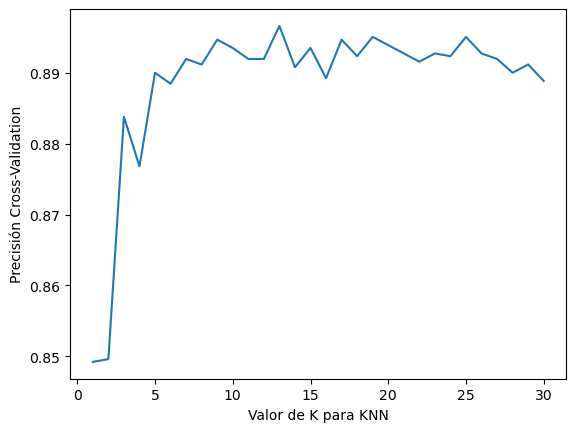

In [12]:
plt.plot(k_range, k_scores)
plt.xlabel('Valor de K para KNN')
plt.ylabel('Precisión Cross-Validation')
plt.show()

# Optimización de Hiperparámetros con GridSearchCV

A continuación exploramos métodos automatizados para la búsqueda de los mejores hiperparámetros.

## 12. Importación de GridSearchCV

`GridSearchCV` es una herramienta que automatiza la búsqueda exhaustiva de los mejores hiperparámetros:
- Prueba todas las combinaciones posibles de parámetros
- Utiliza validación cruzada para evaluar cada combinación
- Es más eficiente que el método manual anterior

In [13]:
from sklearn.model_selection import GridSearchCV

## 13. Inicialización del Modelo KNN

Creamos una nueva instancia del clasificador KNN que será utilizada por GridSearchCV.

In [14]:
knn = KNeighborsClassifier()

## 14. Definición de la Grilla de Parámetros

Creamos un diccionario con los parámetros a explorar:
- **n_neighbors**: Probamos valores de K desde 1 hasta 30
- GridSearchCV probará cada uno de estos valores de forma exhaustiva

La grilla define el espacio de búsqueda de hiperparámetros.

In [15]:
k_range=list(range(1,31))
param_grid = dict(n_neighbors=k_range)
print(param_grid)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}


## 15. Configuración de Folds para GridSearchCV

Reutilizamos la misma estrategia de validación cruzada estratificada (10 folds) para garantizar consistencia en la comparación de resultados.

In [16]:
folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=19)


## 16. Creación del Objeto GridSearchCV

Configuramos GridSearchCV con:
- **knn**: El modelo a optimizar
- **param_grid**: Los parámetros a explorar
- **cv**: La estrategia de validación cruzada (10 folds)
- **scoring='accuracy'**: La métrica a optimizar (precisión)

GridSearchCV ejecutará 30 valores de K × 10 folds = 300 ajustes de modelo.

In [17]:
grid = GridSearchCV(knn, param_grid, cv=folds, scoring='accuracy')


## 17. Entrenamiento con GridSearchCV

Ejecutamos la búsqueda exhaustiva:
- GridSearchCV prueba todas las combinaciones de parámetros
- Evalúa cada combinación usando validación cruzada
- Identifica automáticamente la mejor configuración

Este proceso puede tomar tiempo dependiendo del tamaño de la grilla y los datos.

In [18]:
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=19, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy')

## 18. Resultados de la Búsqueda

Examinamos los resultados detallados de GridSearchCV:
- `cv_results_`: Contiene todos los scores, tiempos, y parámetros probados
- Mostramos las primeras 3 configuraciones para entender la estructura de los resultados

In [19]:
pd.DataFrame(grid.cv_results_).head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003813,0.001387,0.016926,0.001073,1,{'n_neighbors': 1},0.879845,0.860465,0.813953,0.856031,0.824903,0.821012,0.856031,0.840467,0.867704,0.871595,0.849201,0.021695,30
1,0.003276,0.000241,0.016235,0.000612,2,{'n_neighbors': 2},0.844961,0.852713,0.833333,0.844358,0.832685,0.852140,0.863813,0.828794,0.867704,0.875486,0.849599,0.014996,29
2,0.003006,0.000074,0.015519,0.000490,3,{'n_neighbors': 3},0.922481,0.875969,0.856589,0.887160,0.887160,0.887160,0.875486,0.867704,0.883268,0.894942,0.883792,0.016687,27


## 19. Mejor Estimador

`best_estimator_` devuelve el modelo KNN ya entrenado con el mejor valor de K encontrado. Este modelo está listo para hacer predicciones sin necesidad de reentrenamiento.

In [20]:
grid.best_estimator_

KNeighborsClassifier(n_neighbors=13)

## 20. Mejor Score de Validación Cruzada

`best_score_` muestra la precisión promedio obtenida por el mejor modelo durante la validación cruzada. Esta es la métrica que GridSearchCV utilizó para seleccionar el mejor K.

In [21]:
grid.best_score_

0.8966171990468436

## 21. Mejores Parámetros

`best_params_` devuelve el diccionario con los valores óptimos de los hiperparámetros encontrados. En este caso, nos indica el valor de K que maximiza la precisión.

In [22]:
grid.best_params_

{'n_neighbors': 13}

## 22. Predicciones en el Conjunto de Prueba

Utilizamos el mejor modelo encontrado para hacer predicciones sobre el conjunto de prueba (X_test). Este conjunto de datos no fue usado durante el entrenamiento ni la validación cruzada, permitiendo evaluar el rendimiento real del modelo.

In [23]:
y_pred_grid = grid.predict(X_test)

## 23. Matriz de Confusión - GridSearchCV

La **matriz de confusión** muestra el rendimiento del clasificador:
- **Verdaderos Negativos (TN)**: Esquina superior izquierda
- **Falsos Positivos (FP)**: Esquina superior derecha
- **Falsos Negativos (FN)**: Esquina inferior izquierda
- **Verdaderos Positivos (TP)**: Esquina inferior derecha

Permite visualizar qué tipos de errores comete el modelo.

In [25]:
from sklearn.metrics import confusion_matrix


confusion = confusion_matrix(y_test, y_pred_grid)
print(confusion)

[[567  78]
 [ 53 405]]


## 24. Reporte de Clasificación - GridSearchCV

El `classification_report` proporciona métricas detalladas por clase:
- **Precision**: TP / (TP + FP) - ¿Cuántos de los predichos positivos son correctos?
- **Recall**: TP / (TP + FN) - ¿Cuántos de los positivos reales fueron detectados?
- **F1-score**: Media armónica de precision y recall
- **Support**: Número de instancias de cada clase
- **Accuracy**: Precisión global del modelo

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90       645
           1       0.84      0.88      0.86       458

    accuracy                           0.88      1103
   macro avg       0.88      0.88      0.88      1103
weighted avg       0.88      0.88      0.88      1103



# Optimización con RandomizedSearchCV

## 25. Importación de RandomizedSearchCV

`RandomizedSearchCV` es una alternativa a GridSearchCV:
- **Búsqueda aleatoria** en lugar de exhaustiva
- Más eficiente cuando el espacio de búsqueda es muy grande
- Permite especificar el número de iteraciones (n_iter)
- Útil cuando hay múltiples hiperparámetros o muchos valores posibles

In [27]:
from sklearn.model_selection import RandomizedSearchCV

## 26. Definición de Parámetros para RandomizedSearchCV

Definimos el mismo rango de valores de K (1-30) para comparar resultados con GridSearchCV.

In [28]:
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range)  
print(param_grid)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}


## 27. Configuración y Entrenamiento con RandomizedSearchCV

Configuramos RandomizedSearchCV:
- **n_iter=20**: Prueba solo 20 combinaciones aleatorias (vs 30 de GridSearchCV)
- **random_state=10**: Para reproducibilidad
- Más rápido que GridSearchCV pero puede perder el óptimo global

RandomizedSearchCV es ideal cuando:
- El espacio de búsqueda es muy grande
- Los recursos computacionales son limitados
- Se busca una solución "suficientemente buena" rápidamente

In [29]:

random = RandomizedSearchCV(knn, param_grid, cv=folds, scoring='accuracy', n_iter=20, random_state=10)
random.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=19, shuffle=True),
                   estimator=KNeighborsClassifier(), n_iter=20,
                   param_distributions={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10, 11, 12, 13, 14,
                                                        15, 16, 17, 18, 19, 20,
                                                        21, 22, 23, 24, 25, 26,
                                                        27, 28, 29, 30]},
                   random_state=10, scoring='accuracy')

## 28. Resultados de RandomizedSearchCV

Exploramos los resultados de las 20 iteraciones aleatorias probadas.

In [30]:
pd.DataFrame(random.cv_results_).head(3)
    

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007524,0.011786,0.018859,0.004394,21,{'n_neighbors': 21},0.922481,0.868217,0.872093,0.898833,0.891051,0.898833,0.879377,0.887160,0.898833,0.910506,0.892738,0.015974,6
1,0.003234,0.000207,0.016553,0.000711,8,{'n_neighbors': 8},0.937984,0.883721,0.875969,0.879377,0.891051,0.910506,0.883268,0.879377,0.879377,0.891051,0.891168,0.018253,14
2,0.002974,0.000115,0.015772,0.000958,6,{'n_neighbors': 6},0.930233,0.875969,0.856589,0.883268,0.894942,0.898833,0.887160,0.875486,0.883268,0.898833,0.888458,0.018433,17


## 29. Mejor Estimador - RandomizedSearchCV

Obtenemos el modelo con el mejor K encontrado por la búsqueda aleatoria.

In [31]:
print(random.best_estimator_)

KNeighborsClassifier(n_neighbors=13)


## 30. Mejor Score - RandomizedSearchCV

Mostramos la precisión del mejor modelo encontrado. Comparar este valor con el de GridSearchCV nos indica si la búsqueda aleatoria encontró una solución comparable.

In [32]:
print(random.best_score_)

0.8966171990468436


## 31. Mejores Parámetros - RandomizedSearchCV

Valor óptimo de K encontrado por RandomizedSearchCV.

In [34]:
print(random.best_params_)

{'n_neighbors': 13}


## 32. Reporte de Clasificación - RandomizedSearchCV

Evaluamos el rendimiento del modelo de RandomizedSearchCV en el conjunto de prueba con métricas detalladas.

In [35]:
print(classification_report(y_test, random.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90       645
           1       0.84      0.88      0.86       458

    accuracy                           0.88      1103
   macro avg       0.88      0.88      0.88      1103
weighted avg       0.88      0.88      0.88      1103



## 33. Matriz de Confusión - RandomizedSearchCV

Matriz de confusión final para el modelo optimizado con RandomizedSearchCV.

## Conclusiones

Este análisis completo nos permite:
1. **Comparar tres enfoques** de búsqueda de hiperparámetros:
   - Búsqueda manual con loop
   - GridSearchCV (búsqueda exhaustiva)
   - RandomizedSearchCV (búsqueda aleatoria)

2. **Evaluar el trade-off** entre:
   - Precisión del resultado vs tiempo de cómputo
   - GridSearchCV es más exhaustivo pero más lento
   - RandomizedSearchCV es más rápido pero puede perder el óptimo

3. **Métricas de evaluación completas**:
   - Validación cruzada para selección de modelo
   - Conjunto de prueba para evaluación final
   - Matriz de confusión y reporte de clasificación para análisis detallado

In [36]:
confusion = confusion_matrix(y_test, random.predict(X_test))
print(confusion)    

[[567  78]
 [ 53 405]]
